# Bank Customer Churn Prediction
## 1. Introduction & Business Problem

### Background
In the highly competitive banking industry, customer retention is a major challenge. Research shows that acquiring a new customer is significantly more expensive than retaining an existing one. Therefore, the ability to predict which customers are likely to leave (Churn) provides immense economic value to the bank.



### Problem Definition
The goal of this project is to build a Machine Learning model that identifies customers at risk of churning based on demographic and financial data such as age, account balance, and number of products.

### Primary Metric: Recall
In this project, we prioritize the **Recall** metric as our key performance indicator. 
**Business Justification:** For a bank, "missing" a customer who is actually about to leave (False Negative) is a very costly event. It is more efficient to provide a "false alarm" (False Positive) and offer a retention incentive than to fail to identify a customer who leaves the bank.

## 2. Data Preprocessing & Feature Engineering

### Overview
Before feeding the data into our Machine Learning models, we must transform the raw dataset into a format that the algorithms can understand. This stage ensures data quality and consistency.

### Key Steps Performed:
* **Variable Encoding:** Converted categorical variables (such as Geography and Gender) into numerical format using One-Hot Encoding. This allows the models to interpret categorical differences mathematically.
* **Feature Scaling:** Applied Scaling (Min-Max/Standard Scaling) to normalize the range of independent variables. This is essential for models like Logistic Regression to prevent features with large numeric ranges (e.g., Balance) from dominating the model over smaller-range features (e.g., Age).
* **Data Cleaning:** Handled missing values and removed irrelevant columns that do not contribute to the predictive power of the model.

In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [143]:
df=pd.read_csv('Customer-Churn-Records.csv')
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [144]:
df=df.drop(columns=['RowNumber', 'Surname', 'CustomerId'])
df.head(3)

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377


<Axes: xlabel='Exited', ylabel='count'>

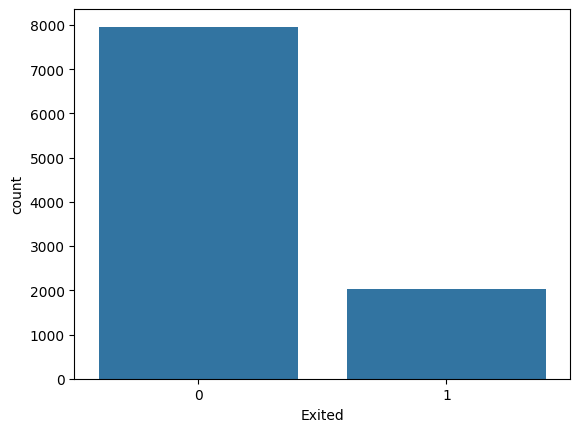

In [145]:
sns.countplot(data=df, x=df['Exited'])

In [146]:
df= df.drop(columns=["Complain"])

<Axes: >

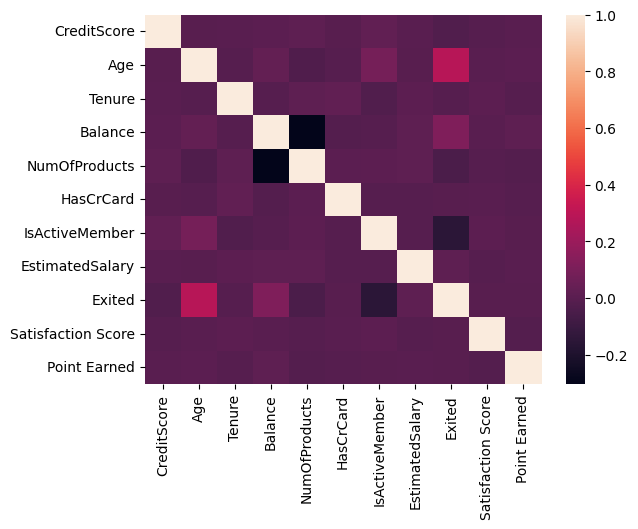

In [147]:
check1=df.corr(numeric_only=True)
sns.heatmap(data=check1)

In [148]:
cat_cols=['Geography','Gender','Card Type']
df= pd.get_dummies(df,columns=cat_cols,drop_first=True)
df.head(3)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Point Earned,Geography_Germany,Geography_Spain,Gender_Male,Card Type_GOLD,Card Type_PLATINUM,Card Type_SILVER
0,619,42,2,0.00,1,1,1,101348.88,1,2,464,False,False,False,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,3,456,False,True,False,False,False,False
2,502,42,8,159660.80,3,1,0,113931.57,1,3,377,False,False,False,False,False,False


In [149]:
df = df.astype(int)

In [150]:
X= df.drop('Exited',axis=1)
y= df['Exited']

In [151]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

In [152]:
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 3. Modeling: Logistic Regression (Baseline)

### Overview
We begin our modeling phase with **Logistic Regression**, a widely used linear model for binary classification. In this project, it serves as our "Baseline" model, providing a point of comparison for more complex algorithms later on.

### Initial Results & Observations:
* **High Accuracy, Low Utility:** While the model achieved a respectable **Accuracy of 81%**, a deeper look into the `classification_report` reveals a major flaw.
* **The Recall Gap:** The **Recall** for the minority class (Churned customers) was only **0.19**. This means the model failed to identify 81% of the customers who actually left the bank.
* **The Imbalance Challenge:** The high accuracy is misleading because the dataset is imbalanced (more customers stayed than left). The model simply "learned" to predict that most customers stay, which is not useful for a proactive retention strategy.



### Conclusion
The Baseline model is insufficient for the bank's needs, as missing 81% of churners would lead to significant financial loss. This necessitates the use of more advanced models like Decision Trees and Random Forests, along with techniques to handle class imbalance.

In [153]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

In [154]:
param_grid = {'C':[0.1,0.5,0.75,1,2],
             'solver':['newton-cg','sag','saga','lbfgs'],
             'max_iter':[50,100,200]}


logreg = LogisticRegression(random_state=42)
grid_logreg = GridSearchCV(logreg,param_grid,verbose=3,scoring='accuracy',cv=5)
grid_logreg.fit(X_train,y_train)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
[CV 1/5] END C=0.1, max_iter=50, solver=newton-cg;, score=0.808 total time=   0.0s
[CV 2/5] END C=0.1, max_iter=50, solver=newton-cg;, score=0.815 total time=   0.0s
[CV 3/5] END C=0.1, max_iter=50, solver=newton-cg;, score=0.810 total time=   0.0s
[CV 4/5] END C=0.1, max_iter=50, solver=newton-cg;, score=0.817 total time=   0.0s
[CV 5/5] END C=0.1, max_iter=50, solver=newton-cg;, score=0.812 total time=   0.0s
[CV 1/5] END ....C=0.1, max_iter=50, solver=sag;, score=0.808 total time=   0.0s
[CV 2/5] END ....C=0.1, max_iter=50, solver=sag;, score=0.814 total time=   0.0s
[CV 3/5] END ....C=0.1, max_iter=50, solver=sag;, score=0.810 total time=   0.0s
[CV 4/5] END ....C=0.1, max_iter=50, solver=sag;, score=0.817 total time=   0.0s
[CV 5/5] END ....C=0.1, max_iter=50, solver=sag;, score=0.812 total time=   0.0s
[CV 1/5] END ...C=0.1, max_iter=50, solver=saga;, score=0.808 total time=   0.0s
[CV 2/5] END ...C=0.1, max_iter=50, s

GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
             param_grid={'C': [0.1, 0.5, 0.75, 1, 2],
                         'max_iter': [50, 100, 200],
                         'solver': ['newton-cg', 'sag', 'saga', 'lbfgs']},
             scoring='accuracy', verbose=3)

In [155]:
grid_logreg.best_estimator_

LogisticRegression(C=1, max_iter=50, random_state=42, solver='sag')

In [156]:
grid_logreg.best_params_

{'C': 1, 'max_iter': 50, 'solver': 'sag'}

In [157]:
logreg = LogisticRegression(C=1, max_iter=50, solver='sag', random_state=42)

logreg.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=50, random_state=42, solver='sag')

In [158]:
predictions_logreg = logreg.predict(X_test)

In [159]:
from sklearn.metrics import classification_report, confusion_matrix

In [160]:
print(classification_report(y_test, predictions_logreg))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      2377
           1       0.62      0.19      0.29       623

    accuracy                           0.81      3000
   macro avg       0.72      0.58      0.59      3000
weighted avg       0.78      0.81      0.77      3000



## 4. Decision Tree Classifier: Handling Imbalance

### Overview
In this stage, we transition to a non-linear model: the **Decision Tree**. Unlike the Baseline model, we specifically addressed the class imbalance using the `class_weight='balanced'` parameter.

### Key Results:
* **Significant Recall Boost:** By prioritizing the minority class, the **Recall jumped from 0.19 to 0.75**.
* **Model Explainability:** The Decision Tree provides a clear, visual flowchart of how the bank's customers are categorized, making it highly interpretable for business stakeholders.
* **The Trade-off:** While Recall improved dramatically, we observed a decrease in Precision, meaning the model produces more "false alarms" (predicting churn for customers who stay).

### Conclusion
The Decision Tree proved that handling class imbalance is the key to identifying churners. However, a single tree can be unstable and prone to overfitting, leading us to our final model: the Random Forest.

In [161]:
from sklearn.tree import DecisionTreeClassifier

In [162]:
param_grid = {'criterion': ['gini','entropy', 'log_loss'],
              'splitter': ['best','random'],
              'max_depth': [5,10,15,20],
              'min_samples_leaf': [2,5,10],
              'class_weight':[None,'balanced']}

DT = DecisionTreeClassifier(random_state=42)
grid_DT = GridSearchCV(DT, param_grid, verbose=3, scoring='recall')
grid_DT.fit(X_train, y_train)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV 1/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=best;, score=0.413 total time=   0.0s
[CV 2/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=best;, score=0.442 total time=   0.0s


[CV 3/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=best;, score=0.420 total time=   0.0s
[CV 4/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=best;, score=0.385 total time=   0.0s
[CV 5/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=best;, score=0.375 total time=   0.0s
[CV 1/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=random;, score=0.261 total time=   0.0s
[CV 2/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=random;, score=0.367 total time=   0.0s
[CV 3/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=random;, score=0.261 total time=   0.0s
[CV 4/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=random;, score=0.230 total time=   0.0s
[CV 5/5] END class_weight=None, criterion=gini, max_depth=5, min_samples_leaf=2, splitter=random

GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'class_weight': [None, 'balanced'],
                         'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [5, 10, 15, 20],
                         'min_samples_leaf': [2, 5, 10],
                         'splitter': ['best', 'random']},
             scoring='recall', verbose=3)

In [163]:
grid_DT.best_params_

{'class_weight': 'balanced',
 'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 10,
 'splitter': 'random'}

In [164]:
DT = DecisionTreeClassifier(class_weight='balanced',criterion='entropy',max_depth=5,min_samples_leaf=10,splitter='random',random_state=42)
DT.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=5, min_samples_leaf=10, random_state=42,
                       splitter='random')

In [165]:
Dt_pred = DT.predict(X_test)

In [166]:
print(classification_report(y_test, Dt_pred))

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      2377
           1       0.43      0.75      0.55       623

    accuracy                           0.74      3000
   macro avg       0.67      0.75      0.68      3000
weighted avg       0.82      0.74      0.76      3000



## 5. Final Model: Random Forest Classifier (Optimized)

### Overview
The **Random Forest** is an ensemble learning method that builds multiple decision trees and merges them together to get a more accurate and stable prediction. 

### Optimization with GridSearchCV:
* **Hyperparameter Tuning:** We utilized `GridSearchCV` to find the optimal combination of parameters, including `n_estimators`, `max_depth`, and `min_samples_leaf`.
* **Scoring Strategy:** The search was optimized specifically for **Recall** to ensure we capture as many potential churners as possible.

### Why this is the Winning Model:
* **Stability:** By averaging the results of many trees, the Random Forest reduces the risk of overfitting to the training data.
* **Robust Performance:** This model maintains the high Recall achieved by the single tree while typically improving overall stability and predictive power on unseen data.

In [167]:
from sklearn.ensemble import RandomForestClassifier

In [168]:
param_grid = {'criterion': ['gini','entropy'],
              'max_depth':[2,4,10],
              'min_samples_leaf': [2,4,6],
              'n_estimators':[100,200],
              'n_jobs':[-1],
              'class_weight': ['balanced']}

RF = RandomForestClassifier(random_state=42)
grid_RF = GridSearchCV(RF,param_grid,verbose=3,scoring='recall',cv=5)
grid_RF.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV 1/5] END class_weight=balanced, criterion=gini, max_depth=2, min_samples_leaf=2, n_estimators=100, n_jobs=-1;, score=0.682 total time=   2.7s
[CV 2/5] END class_weight=balanced, criterion=gini, max_depth=2, min_samples_leaf=2, n_estimators=100, n_jobs=-1;, score=0.710 total time=   0.8s
[CV 3/5] END class_weight=balanced, criterion=gini, max_depth=2, min_samples_leaf=2, n_estimators=100, n_jobs=-1;, score=0.739 total time=   0.6s
[CV 4/5] END class_weight=balanced, criterion=gini, max_depth=2, min_samples_leaf=2, n_estimators=100, n_jobs=-1;, score=0.636 total time=   0.7s
[CV 5/5] END class_weight=balanced, criterion=gini, max_depth=2, min_samples_leaf=2, n_estimators=100, n_jobs=-1;, score=0.707 total time=   0.8s
[CV 1/5] END class_weight=balanced, criterion=gini, max_depth=2, min_samples_leaf=2, n_estimators=200, n_jobs=-1;, score=0.696 total time=   1.9s
[CV 2/5] END class_weight=balanced, criterion=gini, max_depth=

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'class_weight': ['balanced'],
                         'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 10], 'min_samples_leaf': [2, 4, 6],
                         'n_estimators': [100, 200], 'n_jobs': [-1]},
             scoring='recall', verbose=3)

In [169]:
grid_RF.best_params_

{'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 4,
 'min_samples_leaf': 6,
 'n_estimators': 100,
 'n_jobs': -1}

In [170]:
RF = RandomForestClassifier(random_state=42,criterion='gini',max_depth=4,min_samples_leaf=6,n_estimators=100,class_weight='balanced')
RF.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4, min_samples_leaf=6,
                       random_state=42)

In [171]:
FR_pred = RF.predict(X_test)


In [172]:
A = pd.DataFrame(X.columns, columns=['Variables'])
B = pd.DataFrame(RF.feature_importances_, columns=['importance'])

pd.concat((A,B), axis=1).sort_values(by='importance',ascending=False)

,Variables,importance
1,Age,0.452659
4,NumOfProducts,0.239730
10,Geography_Germany,0.085725
6,IsActiveMember,0.085005
3,Balance,0.075882
12,Gender_Male,0.023326
0,CreditScore,0.010626
9,Point Earned,0.007237
7,EstimatedSalary,0.006937
11,Geography_Spain,0.005515


In [173]:
print(classification_report(y_test, FR_pred))

              precision    recall  f1-score   support

           0       0.92      0.78      0.84      2377
           1       0.47      0.75      0.58       623

    accuracy                           0.77      3000
   macro avg       0.70      0.76      0.71      3000
weighted avg       0.83      0.77      0.79      3000



In [174]:
print('Logistic Regression: ')
print('____________________')
print(confusion_matrix(y_test,predictions_logreg))
print()
print(classification_report(y_test,predictions_logreg))

print('Decision Tree: ')
print('____________________')
print(confusion_matrix(y_test,Dt_pred))
print()
print(classification_report(y_test,Dt_pred))

print('Random Forest: ')
print('____________________')
print(confusion_matrix(y_test,FR_pred))
print()
print(classification_report(y_test,FR_pred))

Logistic Regression: 
____________________
[[2305   72]
 [ 504  119]]

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      2377
           1       0.62      0.19      0.29       623

    accuracy                           0.81      3000
   macro avg       0.72      0.58      0.59      3000
weighted avg       0.78      0.81      0.77      3000

Decision Tree: 
____________________
[[1751  626]
 [ 153  470]]

              precision    recall  f1-score   support

           0       0.92      0.74      0.82      2377
           1       0.43      0.75      0.55       623

    accuracy                           0.74      3000
   macro avg       0.67      0.75      0.68      3000
weighted avg       0.82      0.74      0.76      3000

Random Forest: 
____________________
[[1851  526]
 [ 158  465]]

              precision    recall  f1-score   support

           0       0.92      0.78      0.84      2377
           1       0.47      0.75   

## 6. Final Summary & Business Insights

### Model Comparison
After evaluating multiple models, the **Random Forest** was selected as the final model due to its superior ability to identify churners (High Recall) while maintaining model stability.

### Business Insights (Feature Importance):
Based on our analysis, the top factors driving customer churn are:
1. **Age (45% Importance):** Older customers show a significantly higher tendency to leave the bank.
2. **Number of Products (24% Importance):** Customers with fewer or a specific number of products are less "sticky" and more likely to churn.
3. **Geography & Activity:** Customers in Germany and those who are "Inactive Members" represent high-risk segments.

### Actionable Recommendations for the Bank:
* **Targeted Retention:** Implement loyalty programs specifically for customers aged 40+.
* **Product Bundling:** Encourage customers to adopt more products to increase bank-customer engagement (stickiness).
* **Re-engagement Campaigns:** Focus marketing efforts on "Inactive" members to bring them back to the platform before they churn.